In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [97]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class SimpleModel:
    def __init__(self):
        self.W1 = np.array([[0.5, 0.2], [0.3, 0.8]]) # 2x2
        self.b1 = np.zeros((2,1)) # 2x1
        self.W2 = np.array([[0.6, 0.4]]) # 1x2
        self.b2 = np.zeros((1, 1)) # 1x1
        self.lr = 50
        self.y_hat = 0
        self.x = np.zeros((2,1))

    def forward(self, x):
        self.x = x # (2x1)
        self.z1 = self.W1 @ x + self.b1 #  (2x2) x (2x1) = (2x1)
        self.h1 = sigmoid(self.z1)  # (2x1)
        self.z2 = self.W2 @ self.h1 + self.b2 # (1x2) x (2x1) = (1x1)
        self.y_hat = sigmoid(self.z2) # 1x1

        return self.y_hat
    
    def updateState(self, y):
        # delta = dL/dz2
        delta = 2 * (y - self.y_hat) * self.y_hat * (1 - self.y_hat)
        self.W1 = self.W1 + self.lr * delta * (self.W2.T * self.h1 * (1 - self.h1)) @ self.x.T
        self.b1 = self.b1 + self.lr * delta * self.W2.T * self.h1 * (1 - self.h1)
        self.W2 = self.W2 + self.lr * delta * self.h1.T
        self.b2 = self.b2 + self.lr * delta
    
    def changeLr(self, lr):
        """For the lr experiment"""
        self.lr = lr

In [119]:
X = np.array([[[0],[0]], [[0],[1]], [[1],[0]], [[1],[1]]])
y = np.array([[0], [1], [1], [0]])
num_epochs = 10000

def train(num_epochs, lr):
    model = SimpleModel()
    model.changeLr(lr)
    losses = []
    for epoch in range(num_epochs):
        total_loss = np.float64(0)
        for i in range(len(X)):
            x_i = X[i]
            y_i = y[i]
            pred = model.forward(x_i)
            model.updateState(y_i)
            total_loss += (y_i - pred)**2
        losses.append(total_loss.item())

        # if epoch % 1000 == 0:
            # print(f"Epoch {epoch}, Loss: {total_loss.item():.4f}")
    return model,losses

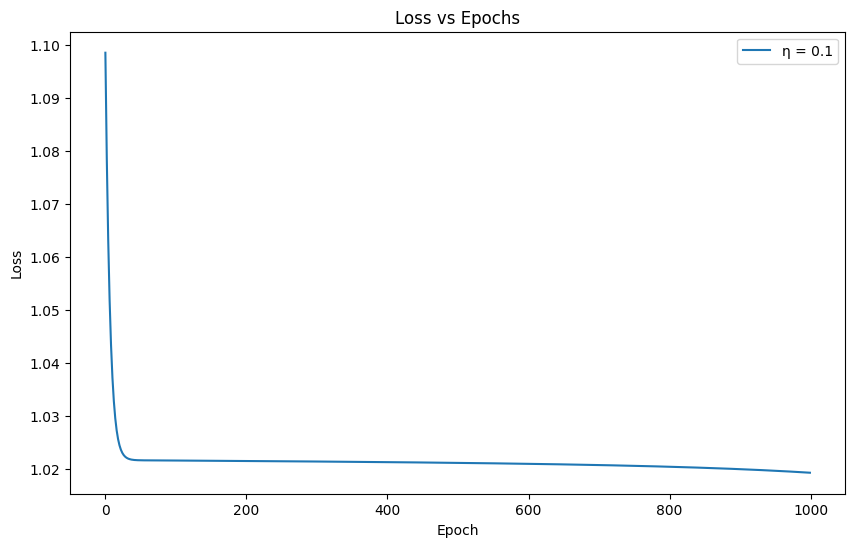

In [131]:
num_epochs = 1000
plt.figure(figsize=(10, 6))
lr = 0.1
_,losses = train(num_epochs, lr)
plt.plot(losses, label=f"η = {lr}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

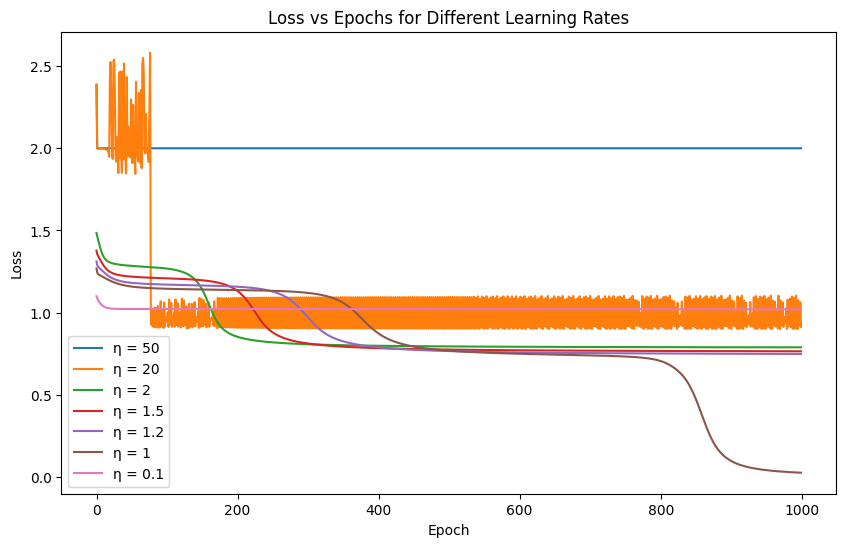

In [137]:
learing_rates = [50, 20, 2, 1.5, 1.2, 1, 0.1]
num_epochs = 1000
plt.figure(figsize=(10, 6))

for lr in learing_rates:
    _,losses = train(num_epochs, lr)
    plt.plot(losses, label=f"η = {lr}")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs for Different Learning Rates')
plt.legend()
# plt.yscale('log')
plt.savefig('loss_curves_lr.png')
plt.show()